**Trading Algorithm Script:** 

This script builds on Version 3, delving into the use of a Markov regime-switching framework. The general workflow is as follows: 

1) Downloading relevant data 
2) Plotting returns 
3) Undertaking stationarity tests 
4) Finding the best AR order for each ticker
5) Fitting a two-regime Markov model 
6) Undertaking diagnostic checks
7) Interpreting results
8) Plotting results through volatility comparisons, transition matrices, and regime scatter/probabilities 


****************************************************************************************************
****************************************************************************************************
*DISCLAIMER:* AI tools such as Claude and ChatGPT were used to fix coding errors, and suggest improvements to optimise the efficiency of the script. 
****************************************************************************************************
****************************************************************************************************


 

In [ ]:
# Installing the necessary packages:

%pip install pandas 
%pip install requests 
%pip install datetime 
%pip install pandas_datareader 
%pip install matplotlib 
%pip install yfinance  
%pip install copy
%pip install seaborn

In [12]:
import pandas_datareader as pdr 
import datetime
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf 
import seaborn as sns 

In [13]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox 
from scipy.stats import normaltest
from typing import Optional, Tuple

plt.style.use('default')

**Importing/Cleaning Data:**


In [58]:
# Here, I create a function for importing data for the specified stocks: 

tickers = ['RTX', 'EADSY', 'RYCEY', 'SAFRY', 'RNMBY', 'BAESY']

def fetch_data(symbol, interval = "1D"):
    end_date = "2026-01-01"
    start_date = "2016-01-01"
    all_data = yf.download(symbol, start = start_date , end = end_date, interval = interval)
    all_data = all_data.dropna()
    return all_data

all_data = fetch_data(tickers)
all_data.head()

[*********************100%***********************]  6 of 6 completed


Price           Close                                                        \
Ticker          BAESY      EADSY      RNMBY        RTX     RYCEY      SAFRY   
Date                                                                          
2016-01-04  21.184273  13.940490  10.976222  47.289604  7.601555  15.397625   
2016-01-05  21.082561  14.007711  11.042997  47.363827  7.619786  15.142968   
2016-01-06  21.620161  13.738820  10.867714  46.077312  7.464837  15.042923   
2016-01-07  21.256918  13.495134  10.383590  45.473625  7.282547  14.824648   
2016-01-08  21.750931  13.268252  10.583917  44.731415  7.419266  14.651845   

Price            High                                   ...       Open  \
Ticker          BAESY      EADSY      RNMBY        RTX  ...      RNMBY   
Date                                                    ...              
2016-01-04  21.249656  13.940490  10.976222  47.324241  ...  10.901100   
2016-01-05  21.118885  14.016115  11.042997  47.502376  ...  10.955355   
2016-01-06  21.787252  13.822850  10.867714  46.829434  ...  10.867714   
2016-01-07  21.460334  13.671597  10.383590  46.191107  ...  10.255882   
2016-01-08  22.506473  13.562355  10.650692  45.463744  ...  10.583917   

Price                                       Volume                          \
Ticker            RTX     RYCEY      SAFRY   BAESY   EADSY RNMBY       RTX   
Date                                                                         
2016-01-04  46.735410  7.647128  15.488574   38400  248200  6900   8552316   
2016-01-05  47.076833  7.674474  15.170253   54400   44500  3000   6758176   
2016-01-06  46.463270  7.483066  14.897403   92900   61200   400  13189653   
2016-01-07  45.260854  7.300777  14.842838  212600  119100   400  11098847   
2016-01-08  45.310351  7.510411  14.961071   61400   66200  1800  11919566   

Price                      
Ticker       RYCEY  SAFRY  
Date                       
2016-01-04  216300  18400  
2016-01-05  127600  39900  
2016-01-06   33000  23800  
2016-01-07  170900  33200  
2016-01-08   50100  22700  

[5 rows x 30 columns]

In [46]:
# Calculating annual returns: 

def annual_returns(data, window=12):
    return data['Close'].pct_change(periods=window)

annual_returns_data = annual_returns(all_data)
annual_returns_data = annual_returns_data.dropna()
annual_returns_data


Ticker,BAESY,EADSY,RNMBY,RTX,RYCEY,SAFRY
Date,,,,,,
2016-01-21,-0.066873,-0.095238,-0.077566,-0.104635,-0.083933,-0.097460
2016-01-22,-0.024810,-0.073185,-0.029478,-0.097890,-0.058612,-0.046246
2016-01-25,-0.055780,-0.058104,-0.009217,-0.088273,-0.051282,-0.029625
2016-01-26,-0.010595,-0.029265,0.065113,-0.068009,-0.012516,-0.020859
2016-01-27,-0.046426,-0.055098,0.064669,-0.050774,-0.058968,-0.032278
...,...,...,...,...,...,...
2025-12-24,0.012910,-0.005855,-0.030037,0.086637,0.037748,0.009757
2025-12-26,0.026688,0.026176,-0.043366,0.077008,0.065408,0.035088
2025-12-29,0.018379,0.014273,-0.047454,0.055517,0.039386,0.004640


In [45]:
# Calculating daily returns: 

def daily_returns(data):
    return np.log(data['Close']/data['Close'].shift(1))
daily_returns_data = daily_returns(all_data)
daily_returns_data = daily_returns_data.dropna()
daily_returns_data

Ticker,BAESY,EADSY,RNMBY,RTX,RYCEY,SAFRY
Date,,,,,,
2016-01-05,-0.004813,0.004810,0.006065,0.001568,0.002395,-0.016677
2016-01-06,0.025180,-0.019383,-0.016000,-0.027538,-0.020545,-0.006629
2016-01-07,-0.016944,-0.017896,-0.045570,-0.013188,-0.024723,-0.014616
2016-01-08,0.022974,-0.016955,0.019109,-0.016456,0.018599,-0.011725
2016-01-11,0.022784,-0.000633,0.000000,0.001105,0.002454,-0.011236
...,...,...,...,...,...,...
2025-12-24,0.000429,-0.003286,-0.001291,0.003332,-0.006361,-0.008264
2025-12-26,0.009381,0.005011,0.007392,-0.006513,0.008262,0.006007
2025-12-29,-0.012384,-0.007960,-0.024100,-0.004059,-0.014664,-0.021703


<Axes: xlabel='Date'>

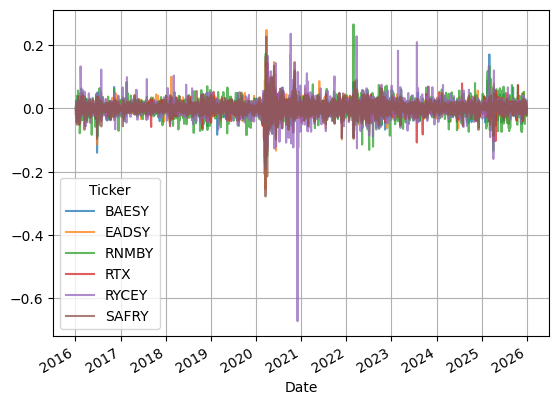

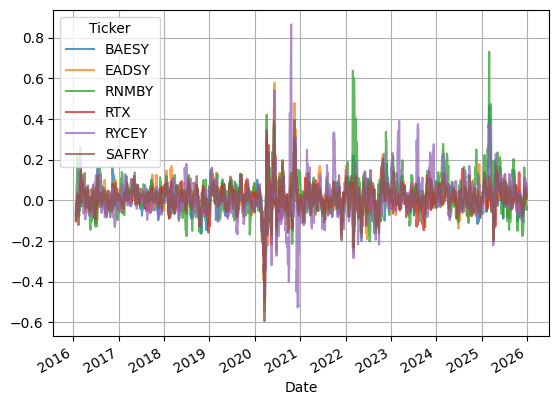

In [39]:
daily_returns_data.plot(grid = True, alpha = 0.75, label = "Daily returns")
annual_returns_data.plot(grid = True, alpha = 0.75, label = "Annual returns")

**Stationarity Tests:**

The above plots indicate that the different returns are mostly stationary, with the exception of a few extreme values around 2020/21, 2022, and 2025. This is to be expected due to events like the Russo-Ukraine war and policy changes under the Trump administration. 

In [47]:
# Conducting stationarity tests: 

for i in tickers:
    print(f"------------------------ADF test for {i}------------------------")
    adf_result = adfuller(daily_returns_data[f"{i}"])
    print(f"ADF Test Statistics: {adf_result[0]: .4f}")
    print(f"ADF p-value: {adf_result[1]:.4f}")
    
    print(f"------------------------KPSS test for {i}------------------------")
    kpss_result = kpss(daily_returns_data[f"{i}"])
    print(f"KPSS Test Statistics: {kpss_result[0]: .4f}")
    print(f"KPSS p-value: {kpss_result[1]:.4f}")
    
    print(f"------------------------Interpretation for {i}------------------------")
    if adf_result[1] > 0.05:
        print("ADF: Series is non-stationary")
    else: 
        print("ADF: Series is stationary")
        
    if kpss_result[1] < 0.05: 
        print("KPSS: Series is non-stationary")
    else: 
        print("KPSS: Series is stationary")
        
    # We see that RTX, EADSY, SAFRY, RMNBY, and BAESY are definitely stationary
    # Unusual result with RYCEY though, as KPSS suggests non-stationarity whilst ADF suggests the opposite 
    # This warrants visual inspection

------------------------ADF test for RTX------------------------
ADF Test Statistics: -13.6325
ADF p-value: 0.0000
------------------------KPSS test for RTX------------------------
KPSS Test Statistics:  0.1021
KPSS p-value: 0.1000
------------------------Interpretation for RTX------------------------
ADF: Series is stationary
KPSS: Series is stationary
------------------------ADF test for EADSY------------------------


C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\1512159040.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(daily_returns_data[f"{i}"])
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\1512159040.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(daily_returns_data[f"{i}"])


ADF Test Statistics: -8.9874
ADF p-value: 0.0000
------------------------KPSS test for EADSY------------------------
KPSS Test Statistics:  0.0450
KPSS p-value: 0.1000
------------------------Interpretation for EADSY------------------------
ADF: Series is stationary
KPSS: Series is stationary
------------------------ADF test for RYCEY------------------------
ADF Test Statistics: -12.5162
ADF p-value: 0.0000
------------------------KPSS test for RYCEY------------------------
KPSS Test Statistics:  0.6432
KPSS p-value: 0.0187
------------------------Interpretation for RYCEY------------------------
ADF: Series is stationary
KPSS: Series is non-stationary
------------------------ADF test for SAFRY------------------------
ADF Test Statistics: -11.2882
ADF p-value: 0.0000
------------------------KPSS test for SAFRY------------------------
KPSS Test Statistics:  0.0626
KPSS p-value: 0.1000
------------------------Interpretation for SAFRY------------------------
ADF: Series is stationary
KPSS:

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\1512159040.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(daily_returns_data[f"{i}"])


ADF Test Statistics: -11.7357
ADF p-value: 0.0000
------------------------KPSS test for BAESY------------------------
KPSS Test Statistics:  0.2019
KPSS p-value: 0.1000
------------------------Interpretation for BAESY------------------------
ADF: Series is stationary
KPSS: Series is stationary


C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\1512159040.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(daily_returns_data[f"{i}"])


<Axes: xlabel='Date'>

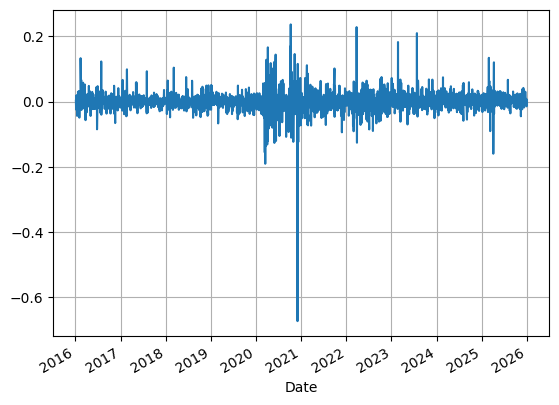

In [50]:
# Visual inspection of RYCEY stationarity: 

daily_returns_data["RYCEY"].plot(grid = True)
    # We therefore see that for the most of the series, returns from RYCEY are quite stationary
    # However, around late 2021, the stock experienced a massive loss, which explains how KPSS is sensitive to outliers

In [63]:
# Finding the best AR model to represent these series: 

# Here, I've created a function that finds the best AR() order based on AIC (Akaike Information Criteria)

def find_best_ar_order(symbol, data:pd.DataFrame, max_order: int = 5) -> int:
    """
    Finds the best AR(p) order based on the AIC criterion.
    Tries orders from 0 up to max_order.
    """
    best_orders = {}
    
    for i in symbol:  
        best_aic = np.inf
        best_order = 0
          
        for order in range(0, max_order + 1):
            try:
                model = MarkovAutoregression(
                    endog=data[i].dropna(),
                    k_regimes=2,
                    order=order,
                    switching_variance=True
                )
                results = model.fit(disp=False)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = order
            except Exception as e:
                print(f"Error for {i}, order {order}: {e}")
   
        best_orders[i] = best_order
    
    return best_orders

best_AR = find_best_ar_order(tickers, all_data['Close'])



c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\regime_switching\markov_autoregression.py:238: RuntimeWarning: divide by zero encountered in divide
  -0.5 * resid**2 / variance - 0.5 * np.log(2 * np.pi * variance))
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\regime_switching\markov_autoregression.py:238: RuntimeWarning: divide by zero encountered in log
  -0.5 * resid**2 / variance - 0.5 * np.log(2 * np.pi * variance))
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\regime_switching\markov_autoregression.py:238: RuntimeWarning: invalid value encountered in subtract
  -0.5 * resid**2 

Error for RTX, order 0: SVD did not converge
Error for RTX, order 1: SVD did not converge
Error for RTX, order 2: SVD did not converge
Error for RTX, order 3: SVD did not converge
Error for RTX, order 4: SVD did not converge
Error for RTX, order 5: SVD did not converge
Error for EADSY, order 0: SVD did not converge
Error for EADSY, order 1: SVD did not converge
Error for EADSY, order 2: SVD did not converge
Error for EADSY, order 3: SVD did not converge
Error for EADSY, order 4: SVD did not converge
Error for EADSY, order 5: SVD did not converge
Error for RYCEY, order 0: SVD did not converge
Error for RYCEY, order 1: SVD did not converge
Error for RYCEY, order 2: SVD did not converge


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

Error for RYCEY, order 3: SVD did not converge
Error for RYCEY, order 4: SVD did not converge
Error for RYCEY, order 5: SVD did not converge
Error for SAFRY, order 0: SVD did not converge
Error for SAFRY, order 1: SVD did not converge
Error for SAFRY, order 2: SVD did not converge
Error for SAFRY, order 3: SVD did not converge
Error for SAFRY, order 4: SVD did not converge
Error for SAFRY, order 5: SVD did not converge
Error for RNMBY, order 0: SVD did not converge
Error for RNMBY, order 1: SVD did not converge
Error for RNMBY, order 2: SVD did not converge
Error for RNMBY, order 3: SVD did not converge
Error for RNMBY, order 4: SVD did not converge
Error for RNMBY, order 5: SVD did not converge
Error for BAESY, order 0: SVD did not converge
Error for BAESY, order 1: SVD did not converge
Error for BAESY, order 2: SVD did not converge
Error for BAESY, order 3: SVD did not converge
Error for BAESY, order 4: SVD did not converge
Error for BAESY, order 5: SVD did not converge


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

In [68]:
def find_best_ar(symbols, data: pd.DataFrame, max_order: int = 5):
    best_orders = {}
    
    for sym in symbols:
        best_aic = np.inf
        best_order = 0
        
        series = data[sym].dropna()
        
        for order in range(1, max_order + 1):  # AR(0) not valid here
            try:
                model = MarkovAutoregression(
                    endog=series,
                    k_regimes=2,
                    order=order,
                    switching_variance=True
                )
                
                results = model.fit(disp=False)
                
                print(f"{sym} | order {order} | AIC: {results.aic}")
                
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = order
                    
            except Exception as e:
                print(f"Error for {sym}, order {order}: {e}")
        
        best_orders[sym] = best_order
    
    return best_orders


best_ARs = find_best_ar(tickers, daily_returns_data)


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RTX | order 1 | AIC: -14417.013300839659


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RTX | order 2 | AIC: -14423.187316112493


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

BAESY | order 3 | AIC: -14024.059055142481


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


BAESY | order 4 | AIC: -14016.631226597354


c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


BAESY | order 5 | AIC: -14011.858828159486


In [ ]:
best_ARs
    # We see that the returns for the stocks mostly follow an AR(1) process
    # This is apart from RTX, which follows an AR(2) process 


{'RTX': 2, 'EADSY': 1, 'RYCEY': 1, 'SAFRY': 1, 'RNMBY': 1, 'BAESY': 1}

In [70]:
# Function for fitting the 2-regime Markov model across all stocks:

def fit_mrs_model(data: pd.DataFrame, best_orders: dict):
    models = {}
    
    for ticker, order in best_orders.items():
        try:
            series = data[ticker].dropna()
            
            model = MarkovAutoregression(
                endog=series,
                k_regimes=2,
                order=order,
                switching_variance=True
            )
            
            results = model.fit(disp=False, maxiter=1000)
            models[ticker] = results
            
        except Exception as e:
            print(f"Error fitting {ticker}: {e}")
    
    return models 

mrs_model = fit_mrs_model(daily_returns_data, best_ARs)

c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

<Axes: xlabel='Date'>

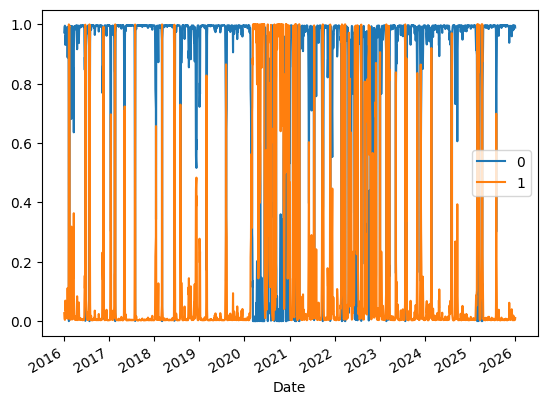

In [81]:
# Example plot for smoothed probabilities: 

mrs_model['RYCEY'].smoothed_marginal_probabilities.plot()


In [82]:
def diagnose_all_models(models: dict) -> None:
    """
    Runs diagnostics for multiple fitted Markov models.
    """
    
    for ticker, results in models.items():
        print(f"\n==============================")
        print(f"Diagnostics for {ticker}")
        print(f"==============================")
        
        resid = results.resid
        
        # Drop NaNs (important!)
        resid = resid[~np.isnan(resid)]
        
        print("\nLjung-Box Test (lag=10):")
        lb_test = acorr_ljungbox(resid, lags=[10], return_df=True)
        print(lb_test)
        
        print("\nNormality Test (D'Agostino-Pearson):")
        normality = normaltest(resid)
        print(f"Statistic: {normality.statistic:.4f}")
        print(f"p-value: {normality.pvalue:.4f}")
        
        if normality.pvalue < 0.05:
            print("Conclusion: Residuals are NOT normally distributed.")
        else:
            print("Conclusion: Residuals appear normally distributed.")

In [83]:
diagnostics = diagnose_all_models(mrs_model)


Diagnostics for RTX

Ljung-Box Test (lag=10):
      lb_stat     lb_pvalue
10  72.936763  1.197710e-11

Normality Test (D'Agostino-Pearson):
Statistic: 530.4934
p-value: 0.0000
Conclusion: Residuals are NOT normally distributed.

Diagnostics for EADSY

Ljung-Box Test (lag=10):
     lb_stat     lb_pvalue
10  93.75211  9.625379e-16

Normality Test (D'Agostino-Pearson):
Statistic: 622.4157
p-value: 0.0000
Conclusion: Residuals are NOT normally distributed.

Diagnostics for RYCEY

Ljung-Box Test (lag=10):
      lb_stat  lb_pvalue
10  33.750867   0.000204

Normality Test (D'Agostino-Pearson):
Statistic: 2224.9534
p-value: 0.0000
Conclusion: Residuals are NOT normally distributed.

Diagnostics for SAFRY

Ljung-Box Test (lag=10):
       lb_stat     lb_pvalue
10  148.398115  7.959137e-27

Normality Test (D'Agostino-Pearson):
Statistic: 891.7486
p-value: 0.0000
Conclusion: Residuals are NOT normally distributed.

Diagnostics for RNMBY

Ljung-Box Test (lag=10):
      lb_stat     lb_pvalue
10  15

These diagnostics tell us that the Markov 2-regime model is not fully capturing the structure in the data, because the residuals are NOT white noise. Whilst the residuals show that they do not follow a Gaussian distribution, this is to be expected. 

This indicates a key limitation of this model in not being able to capture the volatility of different returns accurately (in particular, volatility clustering), and indicates the need for GARCH-type models that more directly acount for fat-tailed distributions and volatility clustering to be used in combination with Markov regime-switching. In essence, my model is too simple for modelling financial returns. 

Whilst I will aim to implement this, this is currently beyond my technical skillset. 


**Examination of volatility:**

In [84]:
def plot_volatility_comparison_all(models: dict) -> None:
    """
    Plots regime variances for multiple Markov models (one per ticker).
    """
    
    for ticker, results in models.items():
        
        variance_params = [
            p for p in results.model.param_names
            if p.startswith('sigma2')
        ]
        
        variances = [
            results.params[results.model.param_names.index(p)]
            for p in variance_params
        ]
        
        plt.figure(figsize=(6, 4))
        
        sns.barplot(
            x=[f"Regime {i+1}" for i in range(len(variances))],
            y=variances,
            palette="Blues_d"
        )
        
        plt.title(f"Estimated Variance by Regime ({ticker})")
        plt.ylabel("Variance")
        plt.xlabel("Regime")
        
        plt.tight_layout()
        plt.show()

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


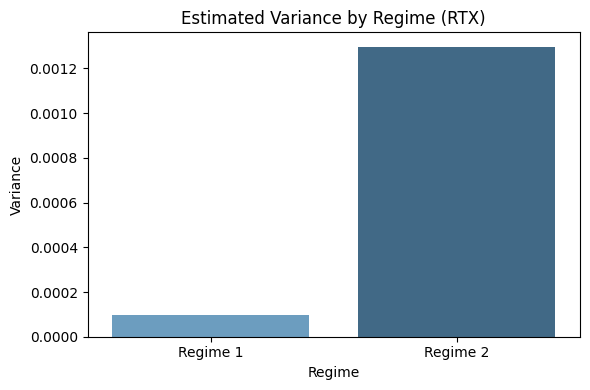

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


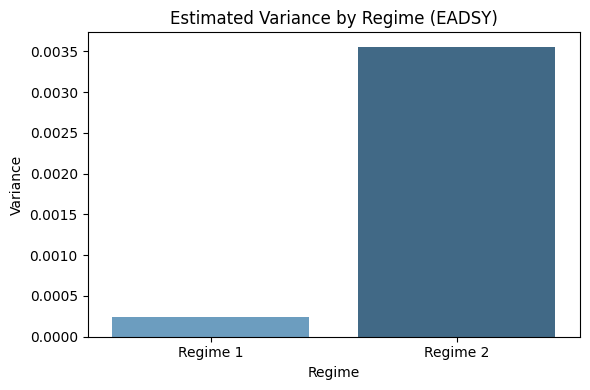

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


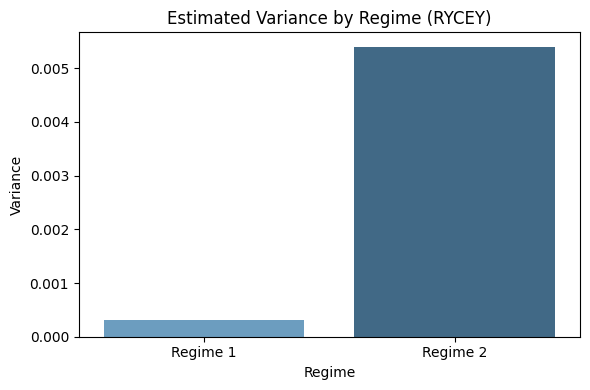

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


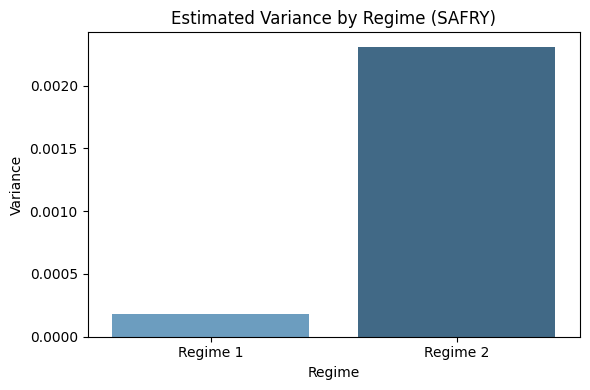

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


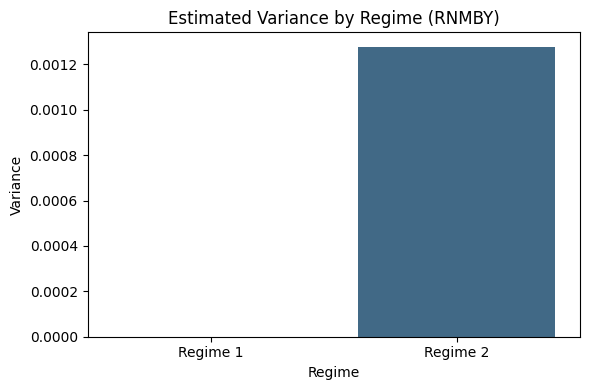

C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[results.model.param_names.index(p)]
C:\Users\abhik\AppData\Local\Temp\ipykernel_11872\3004647717.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


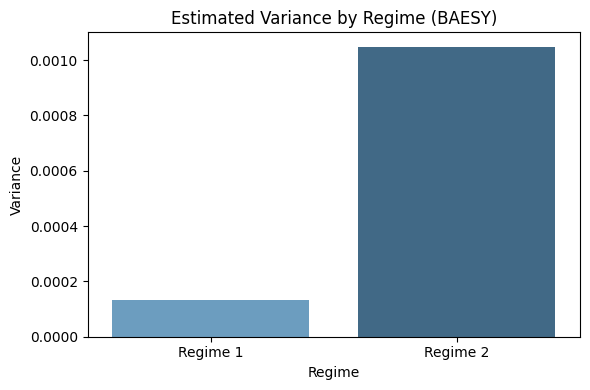

In [85]:
plot_volatility_comparison_all(mrs_model)

In [87]:
# Directly comparing the volatility of different tickers: 

def plot_volatility_grouped(models: dict) -> None:
    """
    Creates a grouped bar chart of regime variances across tickers.
    """
    
    rows = []
    
    for ticker, results in models.items():
        
        variance_params = [
            p for p in results.model.param_names
            if p.startswith('sigma2')
        ]
        
        variances = [
            results.params[p] for p in variance_params
        ]
        
        for i, var in enumerate(variances):
            rows.append({
                "Ticker": ticker,
                "Regime": f"Regime {i+1}",
                "Variance": var
            })
    
    df = pd.DataFrame(rows)
    
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        data=df,
        x="Ticker",
        y="Variance",
        hue="Regime"
    )
    
    plt.title("Regime Volatility Comparison Across Tickers")
    plt.ylabel("Estimated Variance")
    plt.xlabel("Ticker")
    
    plt.legend(title="Regime")
    plt.tight_layout()
    plt.show()


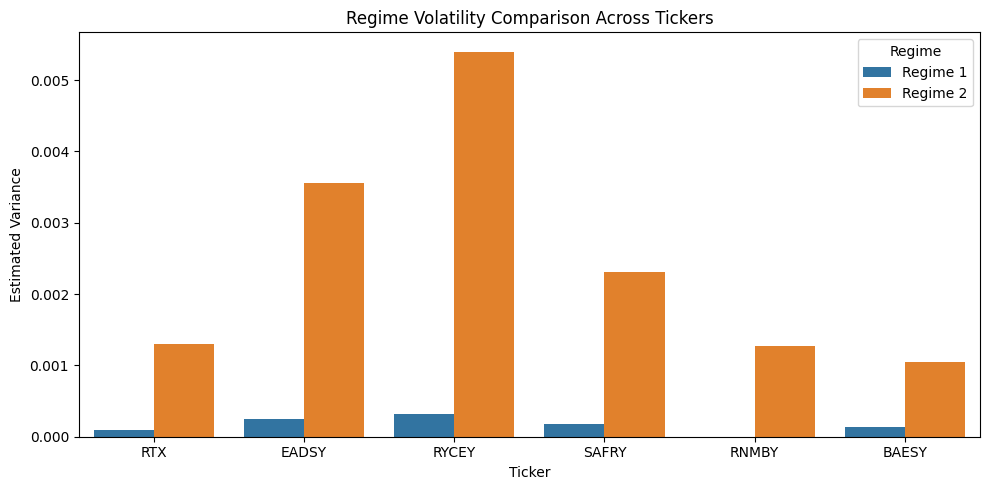

In [89]:
plot_volatility_grouped(mrs_model)

The above plot shows that there is a big difference between a the two states, justifying the need for a Markov regime-swtiching model. RYCEY and EADSY have the highest volatility, indicating that they react strongly to market stress and have large jumps in turbulent regimes. The lower volatility shown by BAESY and RTX, in contrast, show that they are more stable even in a "high volatility" regime. 

This graph essentially indicates that the stocks are all regime-dependent. 

In [90]:
def plot_transition_matrix_all(models: dict) -> None:
    """
    Plots regime transition matrices for multiple Markov models (one per ticker).
    """
    
    for ticker, results in models.items():
        
        transition_matrix = results.regime_transition

        # Handle 3D case (common in Markov models)
        if transition_matrix.ndim == 3:
            transition_matrix = transition_matrix[:, :, 0]

        plt.figure(figsize=(6, 5))

        sns.heatmap(
            transition_matrix,
            annot=True,
            fmt=".4f",
            cmap="Reds",
            xticklabels=[f"Regime {i+1}" for i in range(results.k_regimes)],
            yticklabels=[f"Regime {i+1}" for i in range(results.k_regimes)]
        )

        plt.title(f"Regime Transition Matrix ({ticker})")
        plt.xlabel("Next Regime")
        plt.ylabel("Current Regime")

        plt.tight_layout()
        plt.show()

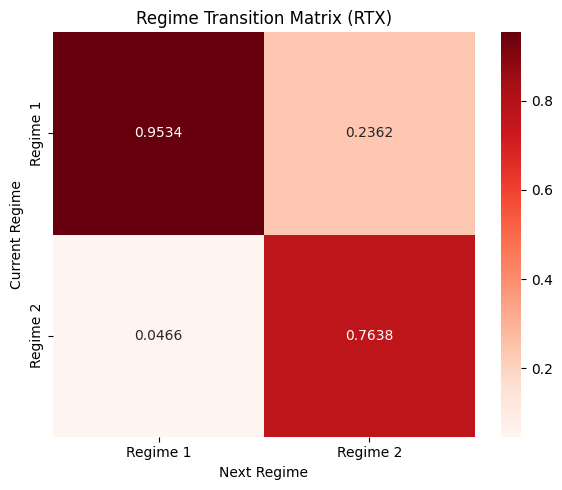

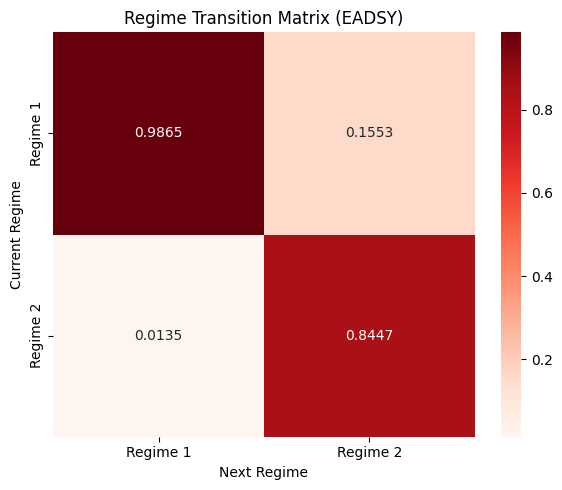

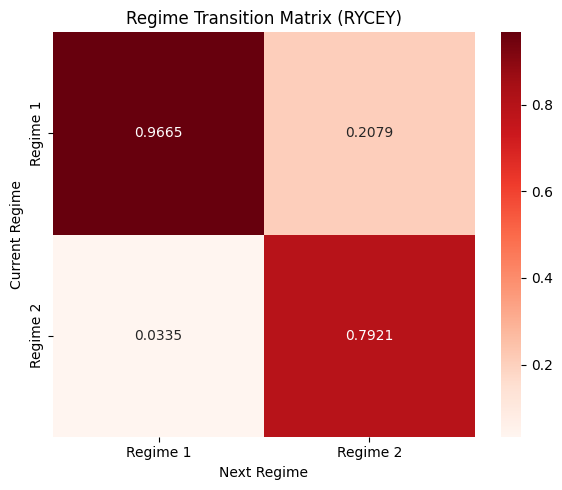

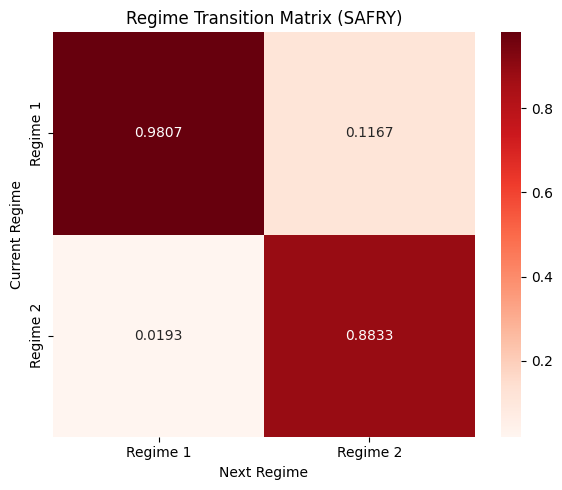

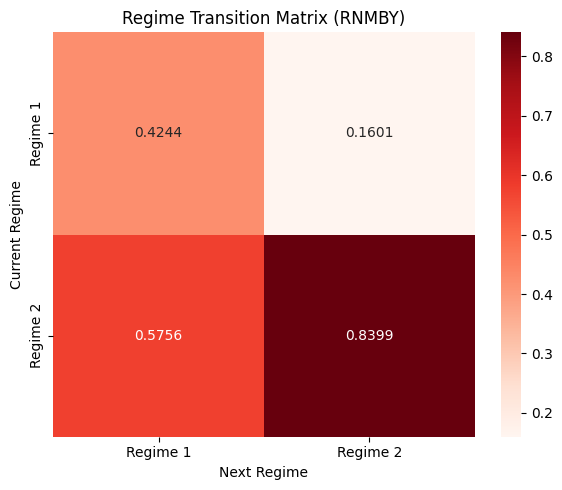

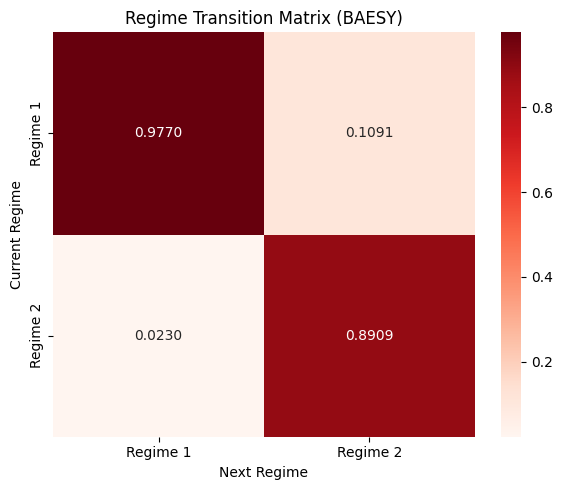

In [91]:
plot_transition_matrix_all(mrs_model)

For most tickers, the high values across the diagonal indicate that the regime is stable and persistent for each stock. RNMBY is the outlier here, as it indicates that when in Regime 2, there is a moderately high chance of it switching back to Regime 1. Given that Regime 2 is the high volatility regime (as indicated by the variance estimates), this shows that RNMBY more quickly revenrts to normal conditions and exits high volatility relatively quickly - i.e. it has a greater *mean-reverting tendency* than its fellow defence stocks. 

**Final plots:** 

In [97]:
# Returns plot: 

def plot_returns_all(data: dict) -> None:
    """
    Plots returns for multiple tickers.
    data: dictionary of DataFrames or Series keyed by ticker
    """
    
    n = len(data)
    fig, axes = plt.subplots(n, 1, sharex=True)
    
    if n == 1:
        axes = [axes]
    
    for ax, (ticker, df) in zip(axes, data.items()):
        ax.plot(df.index, df, label=f"{ticker} Returns", color="steelblue")
        ax.set_title(f"Returns: {ticker}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [94]:
# Regime scatter plot: 

def plot_regimes_all(data: dict, models: dict) -> None:
    """
    Scatter plot of regime assignments for multiple tickers.
    """
    
    n = len(models)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=False)
    
    if n == 1:
        axes = [axes]
    
    for ax, (ticker, results) in zip(axes, models.items()):
        
        df = data[ticker]
        
        regimes = results.smoothed_marginal_probabilities.idxmax(axis=1)
        
        for regime in results.smoothed_marginal_probabilities.columns:
            mask = (regimes == regime)
            
            ax.scatter(
                df.index[mask],
                df[mask],
                label=f"Regime {regime+1}",
                alpha=0.6
            )
        
        ax.set_title(f"Regime Assignment: {ticker}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [95]:
# Regime probabilities plot: 

def plot_regime_probabilities_all(models: dict) -> None:
    """
    Plots smoothed regime probabilities for multiple tickers.
    """
    
    n = len(models)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
    
    if n == 1:
        axes = [axes]
    
    for ax, (ticker, results) in zip(axes, models.items()):
        
        for i in range(results.k_regimes):
            ax.plot(
                results.smoothed_marginal_probabilities[i],
                label=f"Regime {i+1}"
            )
        
        ax.set_title(f"Regime Probabilities: {ticker}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_returns_all(daily_returns_data)


In [ ]:
plot_regimes_all(daily_returns_data, mrs_model)


In [ ]:
plot_regime_probabilities_all(mrs_model)